# Processed GPS EDA

Claire Punturieri  
July 3, 2024

# Housekeeping

## Code Status

Complete to lab workflow standards as of 6/2024.

## Conclusions

EDA is conducted here using subjects with credible lapse reporting and at least one month of data (generated using mak_study_dates.qmd).

## Set up

## Environment

In [ ]:

options(conflicts.policy = "depends.ok")
devtools::source_url("https://github.com/jjcurtin/lab_support/blob/main/format_path.R?raw=true", 
                      sha1 = "a58e57da996d1b70bb9a5b58241325d6fd78890f")


### Paths

In [ ]:
path_shared <- format_path("studydata/risk/data_processed/shared")
path_gps <- format_path("studydata/risk/data_processed/gps")
path_maps <- format_path("studydata/risk/data_processed/gps/subject-maps")
path_notes <- format_path("GitHub/analysis_risk/shared/notes")


## Packages and plot settings

In [ ]:

library(tidyverse)


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.4
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.0
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

## Examine individual participant data

### Load in data

In [ ]:
gps <- read_csv(here::here(path_shared, "gps.csv"), show_col_types = FALSE) |>
  relocate(subid)  |>
  mutate(date = date(time)) |> 
  glimpse()


Rows: 1,240,941
Columns: 13
$ subid           <dbl> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ lat             <dbl> 43.07284, 43.07284, 43.07284, 43.07284, 43.07284, 43.0…
$ lon             <dbl> -89.40627, -89.40627, -89.40627, -89.40627, -89.40627,…
$ time            <dttm> 2017-03-01 15:47:24, 2017-03-01 18:03:11, 2017-03-01 …
$ accuracy        <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ sgmnt_type      <chr> "place", "place", "place", "place", "place", "move", "…
$ trckpnt_type    <chr> "unknown", "walking", "walking", "walking", "unknown",…
$ app_source      <chr> "moves", "moves", "moves", "moves", "moves", "moves", …
$ data_type       <chr> "gps", "gps", "gps", "gps", "gps", "gps", "gps", "gps"…
$ speed_kmh       <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ altitude_meters <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ direction       <dbl> NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA, NA…
$ date      

Rows: 151
Columns: 7
$ subid       <dbl> 1, 2, 3, 5, 6, 7, 9, 10, 11, 15, 16, 18, 19, 20, 21, 23, 2…
$ study_start <dttm> 2017-03-02 06:00:00, 2017-03-24 05:00:00, 2017-03-22 05:0…
$ data_start  <dttm> 2017-03-02 06:00:00, 2017-03-24 05:00:00, 2017-03-22 05:0…
$ study_end   <dttm> 2017-05-31 05:00:00, 2017-06-16 05:00:00, 2017-06-20 05:0…
$ ema_end     <dttm> 2017-05-30 16:10:53, 2017-06-16 14:18:40, 2017-06-20 02:0…
$ start_gps   <dttm> 2017-03-01 15:47:24, 2017-03-23 21:00:23, 2017-03-21 20:1…
$ end_gps     <dttm> 2017-06-05 13:14:59, 2017-04-25 02:12:35, 2017-06-21 23:1…

### Filter subjects with minimum amount of data

Pull list of subject IDs with at least one month data and credible lapse reporting.

In [ ]:
subids_dates <- study_dates |>  
  pull(subid) |>  
  unique()


Filter out subjects not included in study_dates.

In [ ]:
gps <-  gps |>  
  filter(subid %in% subids_dates)

gps |> pull(subid) |> unique() |> length()


[1] 151

### Count number of observations, including missing days

Count n_obs per day by subject – this will only count days for which participants have at least one data point.

In [ ]:
gps_obs <- gps |>
  mutate(date = date(time)) |> 
  group_by(subid, date) |>  
  summarise(n_obs = n())


`summarise()` has grouped output by 'subid'. You can override using the
`.groups` argument.

Create data frame listing out all dates each subject was on study and should have had data.

In [ ]:
dates_long <- study_dates |> 
  select(subid, study_start, study_end) |> 
  pivot_longer(cols = starts_with("study"), names_to = "point",
               values_to = "time") |> 
  mutate(date = date(time)) |> 
  group_by(subid) |>
  complete(date = full_seq(date, 1), fill = list(dummy = 0)) |> 
  select(-time)


Merge with gps_obs. This will create “blank” days for days when subjects were on study but no data points were collected, which we can then fill in with 0s.

In [ ]:
gps_obs <- dates_long |> 
  select(-point) |> 
  left_join(gps_obs, by = c("subid", "date")) |> 
  mutate(n_obs = if_else(is.na(n_obs), 0, n_obs))


### Number of observations per person

Calculate mean number of observations, median number of observations, number of days on study, number of days with 0 observations (AKA missing days), and the percentage of missing data – all **per subject**.

In [ ]:
n_obs <- gps_obs |> 
  group_by(subid) |> 
  summarize(mean_nobs = mean(n_obs), median_nobs = median(n_obs), 
            n_days = n(), n_missing = sum(n_obs == 0), 
            per_missing = n_missing / n_days)


Display histogram of median \# observations per subject.

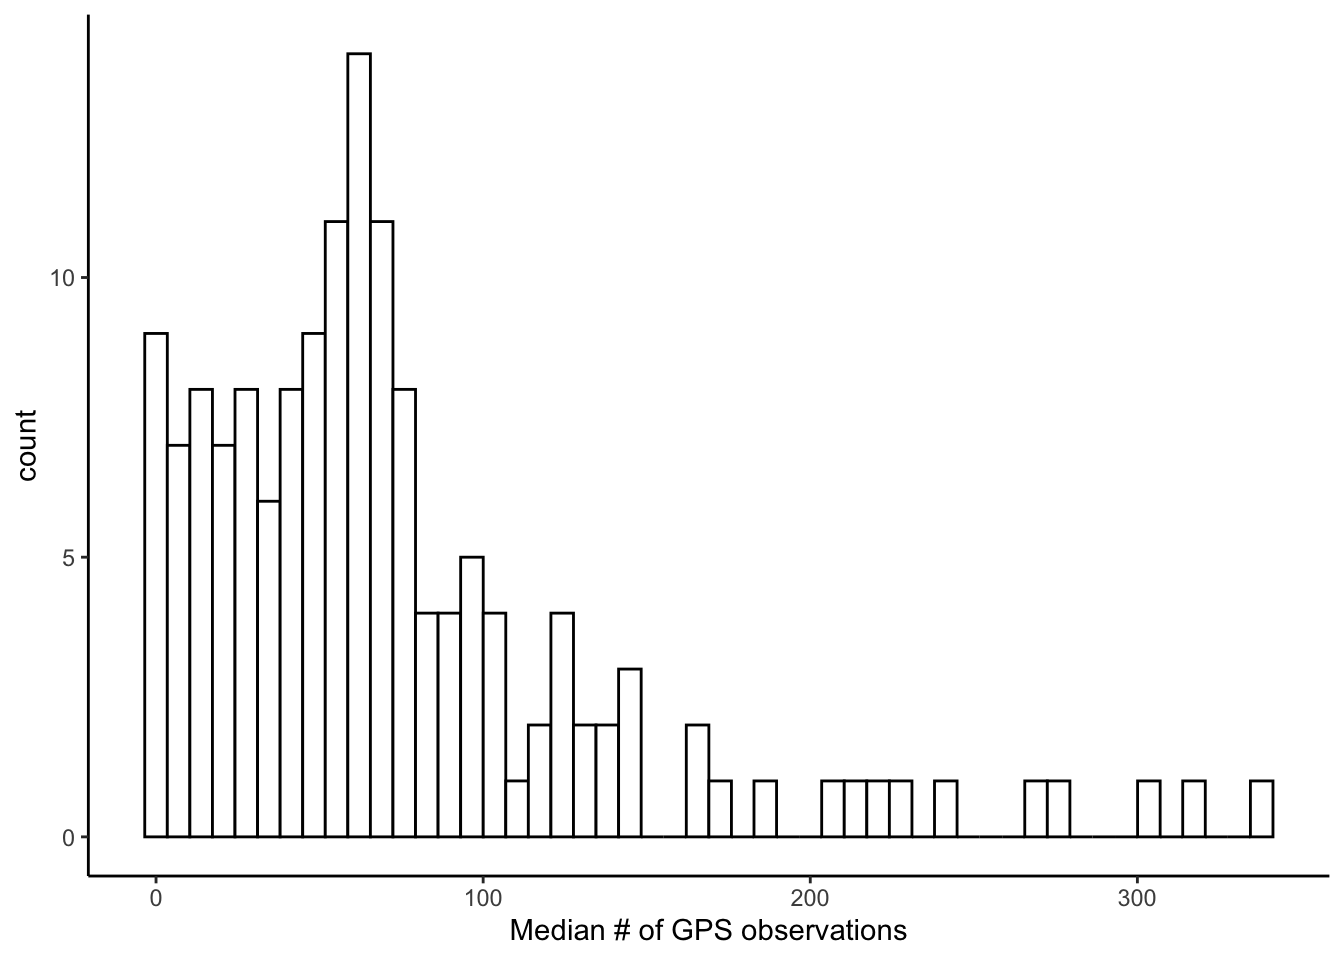

In [ ]:
n_obs |>  
  ggplot(aes(x = median_nobs)) +
  geom_histogram(bins = 50, color = "black", fill = "white") +
  xlab("Median # of GPS observations")


Display histogram of mean \# observations per subject.

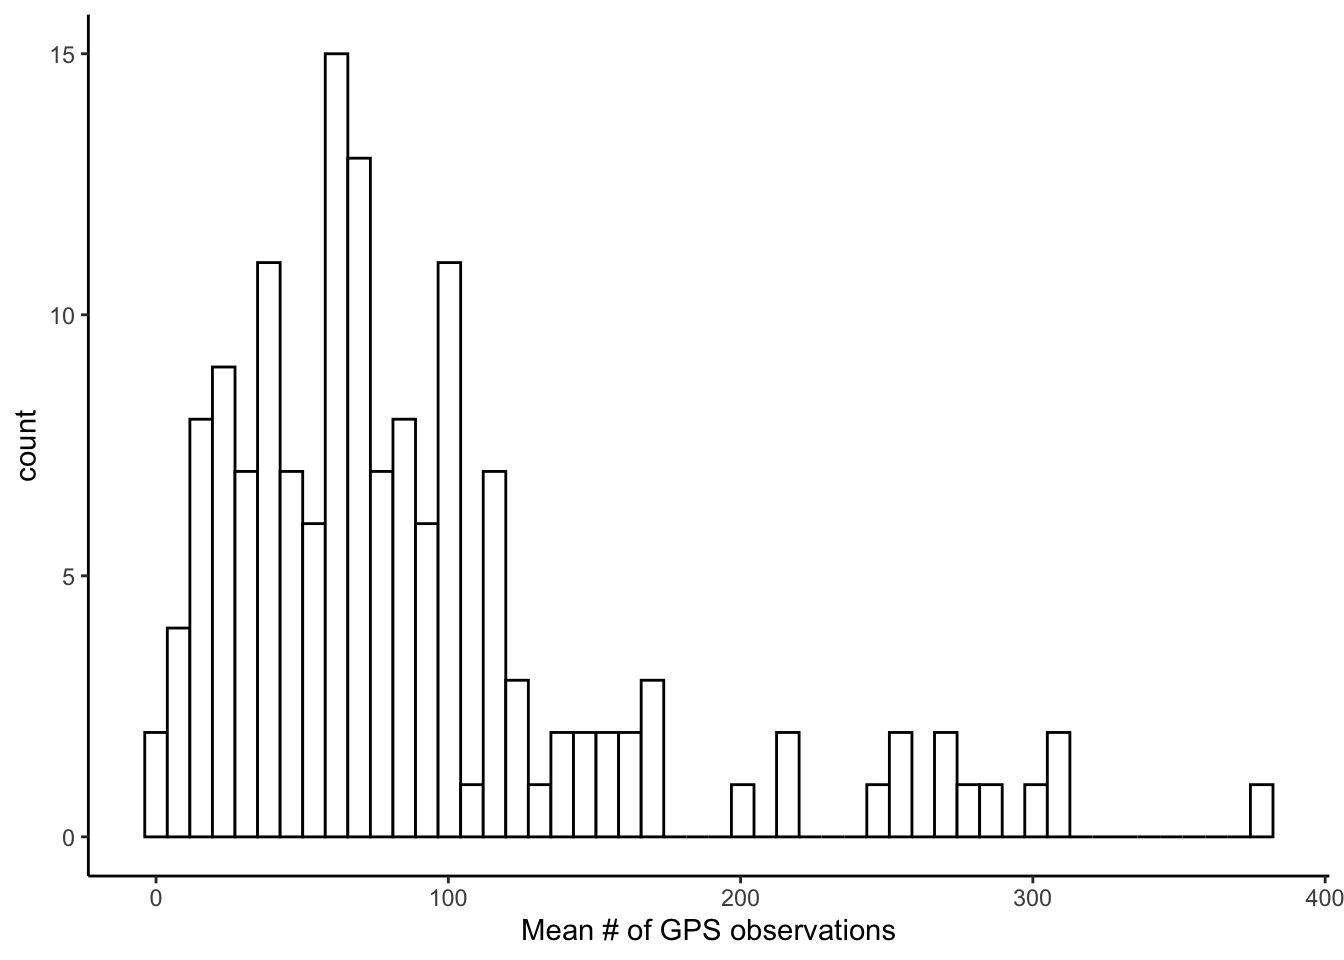

In [ ]:
n_obs |>  
  ggplot(aes(x = mean_nobs)) +
  geom_histogram(bins = 50, color = "black", fill = "white") +
  xlab("Mean # of GPS observations")


Display histogram of percentage of missing observations per subject. Vertical red line indicates missing 25% of data. All subjects with \> 25% of missing data will be individually examined.

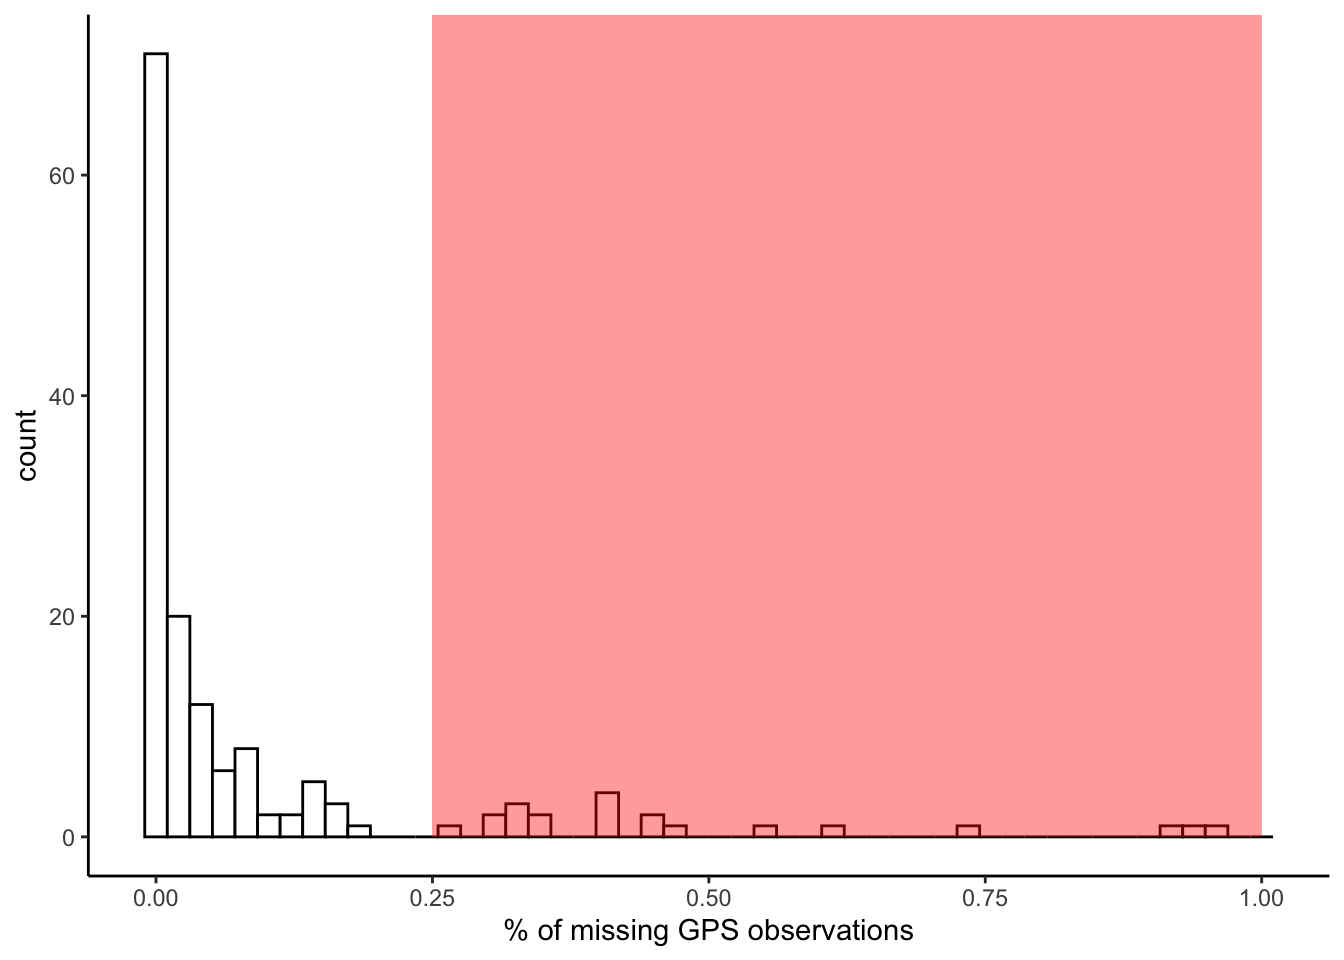

In [ ]:
n_obs |>  
  ggplot(aes(x = per_missing)) +
  geom_histogram(bins = 50, color = "black", fill = "white") +
  annotate("rect", xmin = 0.25, xmax = 1.0, ymin = 0, ymax = Inf, alpha = 0.4, fill = "red") +
  xlab("% of missing GPS observations")


Table listing subjects with high missing data (above \> 25%).

In [ ]:
n_obs |> 
  filter(per_missing > .25) |> 
  arrange(desc(per_missing)) |> 
  print_kbl() |> 
  scroll_box(width = "700px", height = "200px")


Create std_obs, a scaled version of n_obs based on total number of observations and days on study per subject.

In [ ]:
std_obs <- gps_obs |>
  group_by(subid) |> 
  summarize(total_obs = sum(n_obs),
         total_days = n(),
         std_obs = total_obs/total_days)


Display histogram of \# observations per subject on same scale.

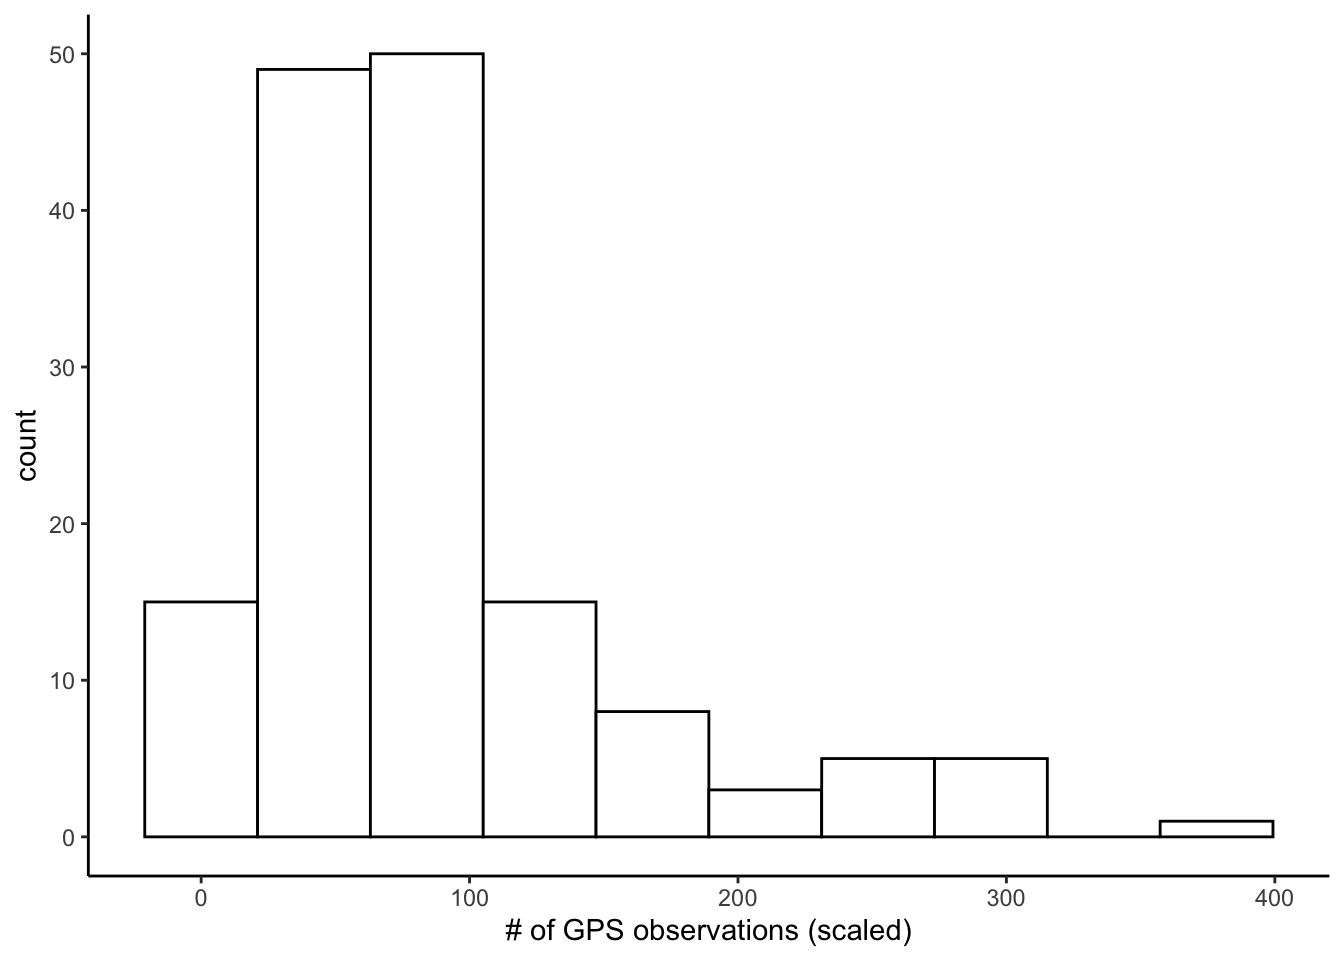

In [ ]:
std_obs |>  
  ggplot(aes(x = std_obs)) +
  geom_histogram(bins = 10, color = "black", fill = "white") +
  xlab("# of GPS observations (scaled)")


### Number of observations per day

**Calculated with missing days included.**

Subset data frame to display average observations per day, SD, minimum observation, and maximum observation per subject.

In [ ]:
obs_per_day <- gps_obs |>
  group_by(subid) |>  
  summarise(avg_obs_per_day = mean(n_obs),
            sd = sd(n_obs),
            min = min(n_obs),
            max = max(n_obs)) 


Display minimum average observation per day and maximum average observation per day across subjects.

In [ ]:
min(obs_per_day$avg_obs_per_day)


[1] 0.4

[1] 378.6923

Display minimum observations per day and maximum observations per day across subjects.

In [ ]:
min(obs_per_day$min)


[1] 0

[1] 2307

Display average observations per day across all subjects (average of average observations per day).

In [ ]:
mean(obs_per_day$avg_obs_per_day)


[1] 88.07377

Histogram of standard deviations (to look at high and low variance subjects).

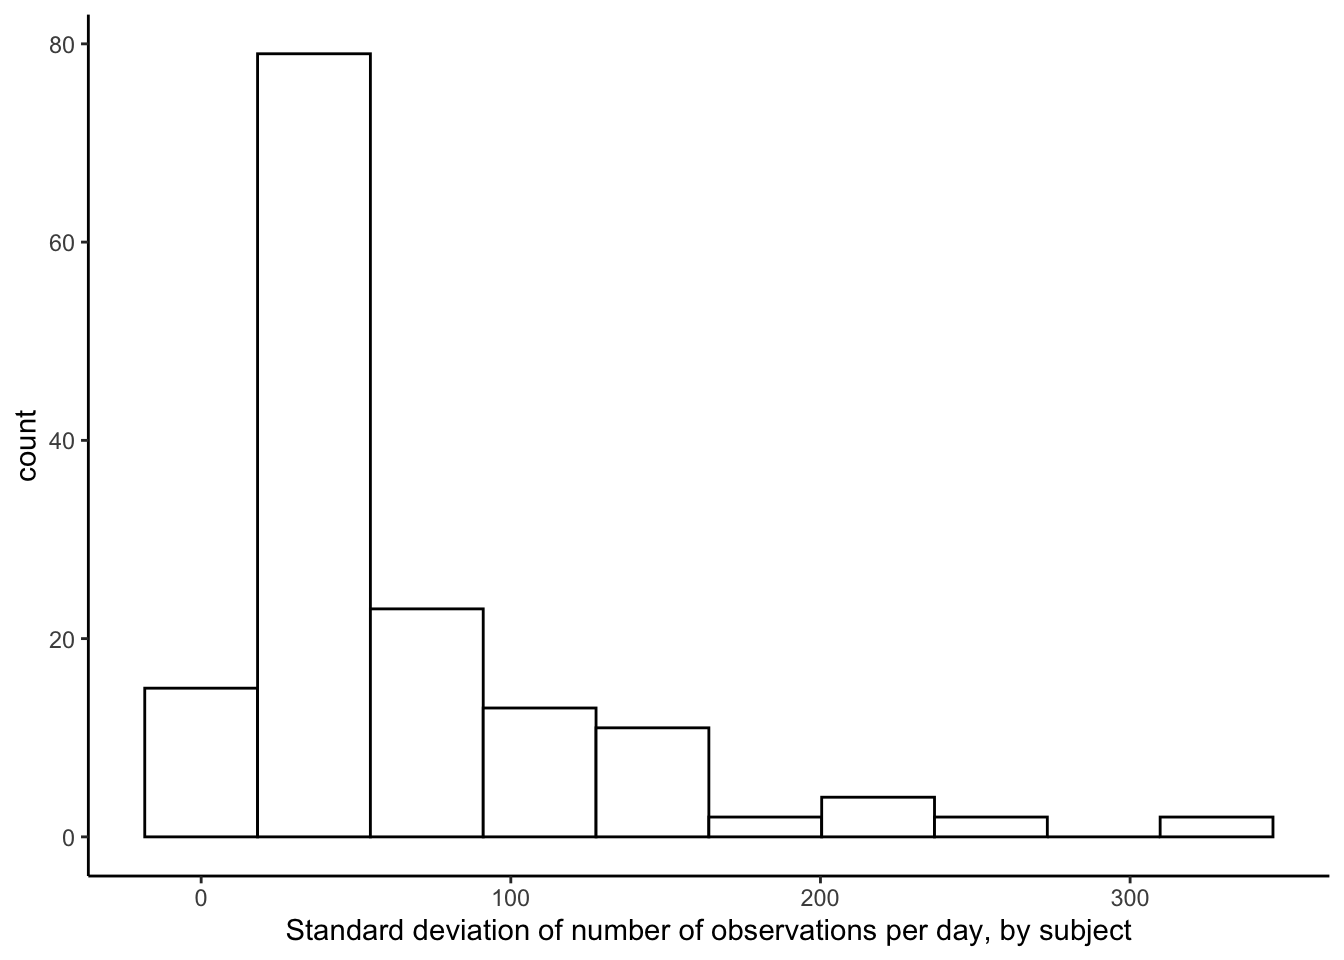

In [ ]:
obs_per_day |>  
  ggplot(aes(x = sd)) +
  geom_histogram(bins = 10, color = "black", fill = "white") +
  xlab("Standard deviation of number of observations per day, by subject")


### Display number of observations by day per subject

In [ ]:
gps_obs |> 
  group_by(subid) |>
  print_kbl() |> 
  scroll_box(width = "700px", height = "200px")


### Examine longest consecutive period of data per subject.

Create function to count number of consecutive observations using rle() (run length encoding). Credit to: https://stackoverflow.com/questions/53712962/r-count-maximum-number-of-consecutive-dates

In [ ]:
gl <- function(x) {
  y <- c(unclass(diff(x)))  # this part makes x into a vector
  r <- rle(y) # rle computes lengths of runs (sequences) in a vector
  with(r, max(lengths[values==1])) # pull out the longest consecutive period of data collection per subject
}


Print table showing subjects with the fewest number of consecutive days of data collection, ascending.

In [ ]:
gps_obs |> 
  filter(n_obs > 0) |>
  group_by(subid) |>
  summarise(max.consecutive = gl(date)) |>
  filter(max.consecutive < 35) |> # looking for ~30 days of data collection
  arrange(max.consecutive) |> 
  print_kbl() |> 
  scroll_box(width = "200px", height = "400px")


ℹ In argument: `max.consecutive = gl(date)`.
ℹ In group 107: `subid = 190`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf

Print table showing subjects with the highest number of consecutive days of 0 data collection, descending.

In [ ]:
gps_obs |> 
  filter(n_obs == 0) |>
  group_by(subid) |>
  summarise(max.consecutive.zeros = gl(date)) |>
  arrange(desc(max.consecutive.zeros)) |>
  filter(!is.infinite(max.consecutive.zeros)) |> 
  print_kbl() |> 
  scroll_box(width = "250px", height = "400px")


The first warning was:
ℹ In argument: `max.consecutive.zeros = gl(date)`.
ℹ In group 4: `subid = 18`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 26 remaining warnings.

### Plot number of observations by day per subject

Create timeseries plotting function, including mean n_obs of non-missing days.

In [ ]:
plot_timeseries <- function(x, y, z) {
    gps_obs <- gps_obs |> filter(subid == z)
    
    graph_title <- paste0("Subject ID", z, sep = " ")
  
    print(ggplot(data = gps_obs, aes(x = .data[[x]], y = .data[[y]], color = z)) +
          geom_line(color = "darkblue")) +
      labs(title = graph_title) +
      geom_hline(aes(yintercept = mean(n_obs[n_obs > 0]), color = "red"), linetype = 2, show.legend = FALSE) +
      coord_cartesian(ylim=c(0, 200))
}


Get list of subjects.

In [ ]:
subid_all <- list(gps_obs$subid) |> unlist() |> unique()


If pdf output file does not already exist, create and save out plots in /data_processed/gps/subject-maps.

In [ ]:
if(file.exists(here::here(path_maps, "per-subj-timeseries.pdf"))){

  message("PDF file already exist -- delete to recreate!")

} else{
  timeseries_plots <- subid_all |>
    map(\(subid) plot_timeseries("date", "n_obs", subid))
  
  output_file <- paste0(path_maps, "/per-subj-timeseries.pdf", sep = "")

  multi.page <- ggpubr::ggarrange(plotlist = timeseries_plots,
                                  nrow = 3, ncol = 1)
  ggpubr::ggexport(multi.page, filename = output_file)
}


### Examine 1-observation days

Filter on days that have only one observation, sorting ascending on time to ensure that the individual points on these days are not all occurring around midnight (which would suggest spurious bursts of activity not actually related to the participant).

In [ ]:
full_join(gps, gps_obs, by=c("subid", "date")) |> 
  select(subid, lat, lon, time, n_obs) |> 
  filter(n_obs == 1) |>
  separate_wider_delim(time, delim = " ", names = c("date_tmp", "time")) |> 
  arrange(time) |>
  select(-date_tmp) |> 
  kable(caption = "1-observation days") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


### Compare start and end dates

Extract first and last dates in GPS data per subject.

In [ ]:
gps_dates <- gps |>
  group_by(subid) |> 
  arrange(date) |> 
  slice(1, n()) |>
  mutate(start_study_gps = first(date),
         end_study_gps = last(date)) |> 
  select(subid, start_study_gps, end_study_gps) |> 
  distinct()


Extract start and end study dates from visit_dates.

In [ ]:
study_dates <- study_dates |>
  select(subid, study_start, study_end) |> 
  mutate(start_study_record = date(study_start),
         end_study_record = date(study_end)) |> 
  select(-study_start, -study_end)


Combine data frames.

In [ ]:
merge_dates <- left_join(gps_dates, study_dates)


Joining with `by = join_by(subid)`

Display comparison table of start and end dates.

In [ ]:
merge_dates |>
  kable(caption = "Comparison of start and end study dates based on staff records and GPS data collection") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


Calculate differences between date start and GPS start.

In [ ]:
merge_dates |>
  mutate(diff = start_study_record - start_study_gps) |>
  select(-end_study_record, -end_study_gps) |> 
  arrange(desc(diff)) |> 
  kable(caption = "Differences between study start and GPS start") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


Calculate differences between date end and GPS end.

> GPS collection ending after the end of study doesn’t matter because we won’t be using that data in any case.

In [ ]:
merge_dates |>
  mutate(diff = end_study_record - end_study_gps) |>
  select(-start_study_record, -start_study_gps) |> 
  arrange(diff) |> 
  kable(caption = "Differences between study end and GPS end") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")


Calculate number of days on study.

> Already calculated above to standardize our \# of GPS observations, but maybe useful to look at in a table?

In [ ]:
merge_dates |>
  mutate(difference = end_study_record - start_study_record) |>
  select(-start_study_gps, -end_study_gps) |> 
  arrange(difference) |> 
  kable(caption = "Number of days on study") |>
  kable_styling("striped") |> 
  scroll_box(width = "700px", height = "400px")
